<a href="https://colab.research.google.com/github/mottupally/Task_Aiml/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Start
   │
   ▼
Load Car Dataset (car_data.csv)
   │
   ▼
Data Preprocessing
• Remove unnecessary column (Car_Name)
• Rename Driven_kms → Kms_Driven
• Create Car_Age feature
• Encode categorical data
   │
   ▼
Split Dataset
(80% Training, 20% Testing)
   │
   ▼
Train Random Forest Regressor Model
   │
   ▼
Evaluate Model
(MAE & R² Score)
   │
   ▼
Save Trained Model
(car_price_model.pkl)
   │
   ▼
User Opens Streamlit Application
   │
   ▼
Enter Car Details
• Year
• Present Price
• Kilometers Driven
• Fuel Type
• Seller Type
• Transmission
• Owner
   │
   ▼
Backend Loads Saved Model
   │
   ▼
Predict Selling Price
   │
   ▼
Display Estimated Car Price
   │
   ▼
End

In [ ]:
!pip install pandas numpy scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving car data.csv to car data.csv


In [ ]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
# Remove Car_Name column
df = df.drop("Car_Name", axis=1)

# Create Car Age feature
df["Car_Age"] = 2025 - df["Year"]

# Drop Year
df = df.drop("Year", axis=1)

# One-hot encoding
df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


In [ ]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
predictions = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, predictions))

print("R2 Score :", r2_score(y_test, predictions))

MAE : 0.6368655737704919
R2 Score : 0.9594566919773236


In [ ]:
with open("car_price_model.pkl","wb") as f:
    pickle.dump(model,f)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
files.download("car_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Example

year = 2018
present_price = 8.5
kms_driven = 25000
owner = 0

fuel_type = "Petrol"
selling_type = "Dealer"
transmission = "Manual"

car_age = 2025 - year

fuel_diesel = 1 if fuel_type == "Diesel" else 0
fuel_petrol = 1 if fuel_type == "Petrol" else 0

selling_type_individual = 1 if selling_type == "Individual" else 0

transmission_manual = 1 if transmission == "Manual" else 0

sample = np.array([[
    present_price,
    kms_driven,
    owner,
    car_age,
    fuel_diesel,
    fuel_petrol,
    selling_type_individual,
    transmission_manual
]])

prediction = model.predict(sample)

print("Predicted Selling Price: ₹", round(prediction[0],2), "Lakhs")

Predicted Selling Price: ₹ 6.79 Lakhs


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

In [ ]:
df.isnull().sum()

,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Owner,0
Car_Age,0
Fuel_Type_Diesel,0
Fuel_Type_Petrol,0
Selling_type_Individual,0
Transmission_Manual,0


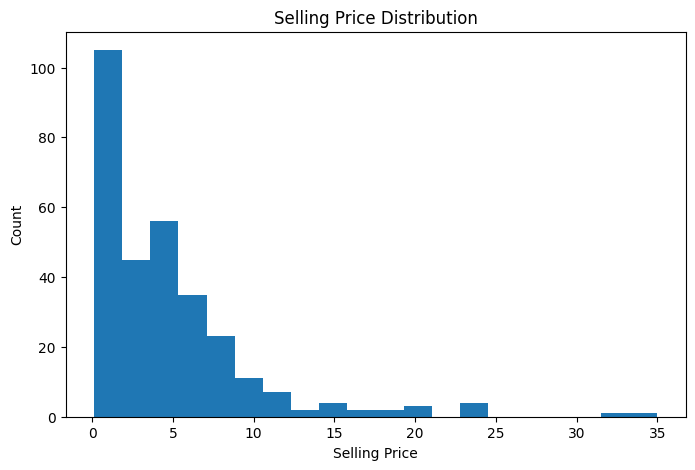

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["Selling_Price"], bins=20)
plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Count")
plt.show()

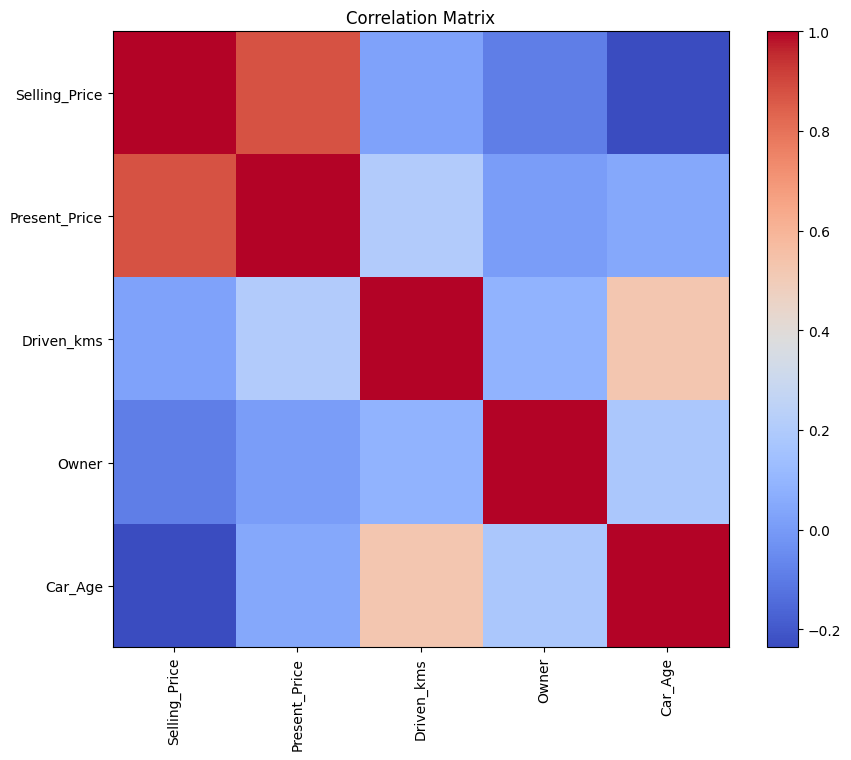

In [ ]:
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

In [ ]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)